Jumlah Data: 365
   id  periode_data     tanggal    jenis_moda  jumlah_penumpang_perhari  \
0   1        202301  2023-01-01  transjakarta                    291030   
1   2        202301  2023-01-02  transjakarta                    666777   
2   3        202301  2023-01-03  transjakarta                    702891   
3   4        202301  2023-01-04  transjakarta                    770560   
4   5        202301  2023-01-05  transjakarta                    752938   

                tipe_hari  
0  Tahun Baru 2023 Masehi  
1                 Weekday  
2                 Weekday  
3                 Weekday  
4                 Weekday  

=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        365 non-null    int64 
 1   periode_data              365 non-null    int64 
 2   tanggal             

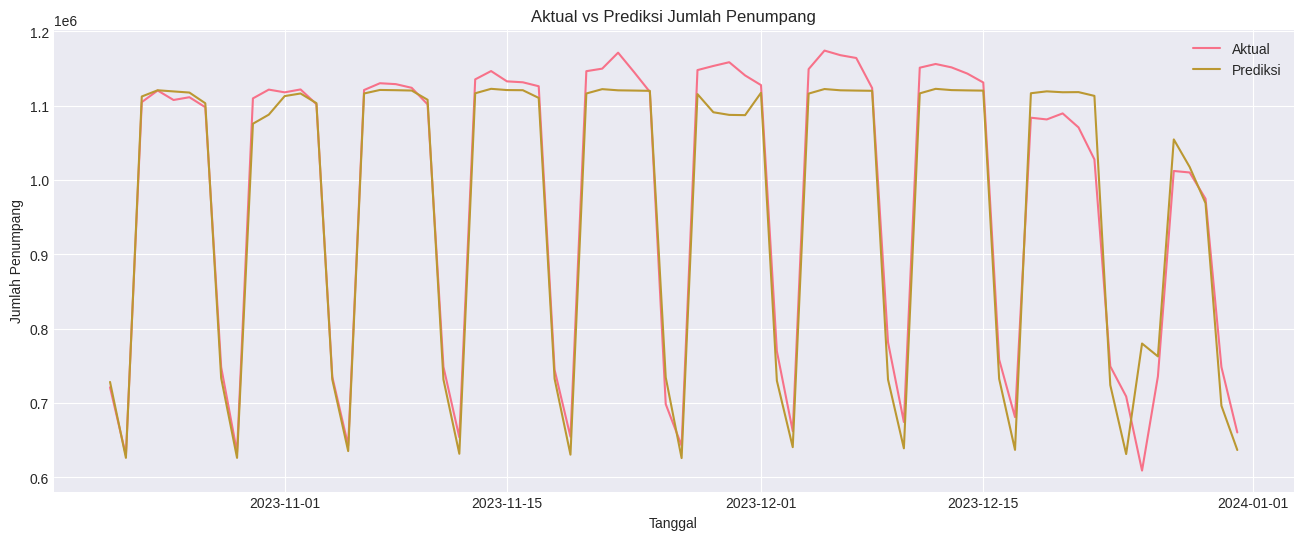


=== FEATURE IMPORTANCE ===
              Feature  Importance
10     rolling_mean_3    0.754502
2   hari_dalam_minggu    0.090179
5   tipe_hari_encoded    0.039846
9               lag_7    0.033755
11     rolling_mean_7    0.022536
3           minggu_ke    0.014641
0               bulan    0.012337
4             kuartal    0.010164
7               lag_2    0.008187
6               lag_1    0.007155
1                hari    0.003705
8               lag_3    0.002992

File berhasil disimpan:
hasil_prediksi_penumpang.csv

Model tersimpan:
model_penumpang.pkl
encoder.pkl
data_terakhir.csv
hasil_training.csv


In [28]:

# =====================================================
# 1. IMPORT LIBRARY
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib


from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# =====================================================
# 2. LOAD DATASET
# =====================================================

df = pd.read_csv('hasil_merge.csv')

print("Jumlah Data:", len(df))
print(df.head())

# =====================================================
# 3. CEK INFORMASI DATA
# =====================================================

print("\n=== INFO DATA ===")
print(df.info())

print("\n=== MISSING VALUE ===")
print(df.isnull().sum())

# =====================================================
# 4. KONVERSI TIPE DATA
# =====================================================

df['tanggal'] = pd.to_datetime(df['tanggal'])

# jika jumlah penumpang masih string seperti 510,507
df['jumlah_penumpang_perhari'] = (
    df['jumlah_penumpang_perhari']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# =====================================================
# 5. FEATURE ENGINEERING
# =====================================================

df['tahun'] = df['tanggal'].dt.year
df['bulan'] = df['tanggal'].dt.month
df['hari'] = df['tanggal'].dt.day
df['hari_dalam_minggu'] = df['tanggal'].dt.dayofweek
df['minggu_ke'] = df['tanggal'].dt.isocalendar().week.astype(int)
df['kuartal'] = df['tanggal'].dt.quarter

# =====================================================
# 6. ENCODE TIPE HARI
# =====================================================

le = LabelEncoder()

df['tipe_hari_encoded'] = le.fit_transform(df['tipe_hari'])

print("\nMapping Tipe Hari:")
for i, label in enumerate(le.classes_):
    print(i, "=", label)

# =====================================================
# 7. MEMBUAT LAG FEATURE
# =====================================================

df['lag_1'] = df['jumlah_penumpang_perhari'].shift(1)
df['lag_2'] = df['jumlah_penumpang_perhari'].shift(2)
df['lag_3'] = df['jumlah_penumpang_perhari'].shift(3)
df['lag_7'] = df['jumlah_penumpang_perhari'].shift(7)

# =====================================================
# 8. MOVING AVERAGE
# =====================================================

df['rolling_mean_3'] = (
    df['jumlah_penumpang_perhari']
    .rolling(window=3)
    .mean()
)

df['rolling_mean_7'] = (
    df['jumlah_penumpang_perhari']
    .rolling(window=7)
    .mean()
)

# =====================================================
# 9. HAPUS NILAI KOSONG
# =====================================================

df = df.dropna()

print("\nJumlah data setelah preprocessing:", len(df))

# =====================================================
# 10. FITUR DAN TARGET
# =====================================================

X = df[
    [
        'bulan',
        'hari',
        'hari_dalam_minggu',
        'minggu_ke',
        'kuartal',
        'tipe_hari_encoded',
        'lag_1',
        'lag_2',
        'lag_3',
        'lag_7',
        'rolling_mean_3',
        'rolling_mean_7'
    ]
]

y = df['jumlah_penumpang_perhari']

# =====================================================
# 11. TRAIN TEST SPLIT TIME SERIES
# =====================================================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nData Train :", len(X_train))
print("Data Test  :", len(X_test))

# =====================================================
# 12. RANDOM FOREST REGRESSOR
# =====================================================

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =====================================================
# 13. PREDIKSI
# =====================================================

y_pred = model.predict(X_test)

# =====================================================
# 14. EVALUASI MODEL
# =====================================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\n==============================")
print("HASIL EVALUASI MODEL")
print("==============================")
print("MAE  :", round(mae,2))
print("RMSE :", round(rmse,2))
print("MAPE :", round(mape*100,2),"%")
print("R2   :", round(r2,4))

# =====================================================
# 15. TABEL HASIL PREDIKSI
# =====================================================

hasil_prediksi = pd.DataFrame({
    'Tanggal': df['tanggal'].iloc[split_index:].values,
    'Aktual': y_test.values,
    'Prediksi': y_pred.astype(int)
})

print("\n=== HASIL PREDIKSI ===")
print(hasil_prediksi.head(20))

# =====================================================
# 16. VISUALISASI AKTUAL VS PREDIKSI
# =====================================================

plt.figure(figsize=(16,6))

plt.plot(
    hasil_prediksi['Tanggal'],
    hasil_prediksi['Aktual'],
    label='Aktual'
)

plt.plot(
    hasil_prediksi['Tanggal'],
    hasil_prediksi['Prediksi'],
    label='Prediksi'
)

plt.title('Aktual vs Prediksi Jumlah Penumpang')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.grid(True)

plt.show()

# =====================================================
# 17. FEATURE IMPORTANCE
# =====================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n=== FEATURE IMPORTANCE ===")
print(importance)


# =====================================================
# 19. SIMPAN HASIL PREDIKSI
# =====================================================

hasil_prediksi.to_csv(
    'hasil_prediksi_penumpang.csv',
    index=False
)

print("\nFile berhasil disimpan:")
print("hasil_prediksi_penumpang.csv")


joblib.dump(
    model,
    "model_penumpang.pkl"
)

joblib.dump(
    le,
    "encoder.pkl"
)

# simpan 7 data terakhir
df.tail(7).to_csv(
    "data_terakhir.csv",
    index=False
)

print("\nModel tersimpan:")
print("model_penumpang.pkl")
print("encoder.pkl")
print("data_terakhir.csv")
print("hasil_training.csv")

In [13]:
import pandas as pd
import numpy as np
import requests
import joblib

# =====================================================
# LOAD MODEL DAN ENCODER
# =====================================================

model = joblib.load("model_penumpang.pkl")
le = joblib.load("encoder.pkl")

print("✅ Model berhasil dimuat")

# =====================================================
# LOAD DATA TERAKHIR
# =====================================================

df_last = pd.read_csv("data_terakhir.csv")

print("✅ Data terakhir berhasil dimuat")

# =====================================================
# AMBIL DATA HARI LIBUR 2026 DARI API
# =====================================================

url = "https://api-hari-libur.vercel.app/api?year=2026"

response = requests.get(url)

if response.status_code != 200:
    raise Exception("Gagal mengambil data hari libur")

data_libur = response.json()["data"]

hari_libur = {
    item["date"]: item["description"]
    for item in data_libur
}

print(f"✅ Berhasil mengambil {len(hari_libur)} hari libur")

# =====================================================
# SEMUA TANGGAL TAHUN 2026
# =====================================================

tanggal_prediksi = pd.date_range(
    start="2026-01-01",
    end="2026-12-31",
    freq="D"
)

print(
    f"✅ Total tanggal yang diprediksi: {len(tanggal_prediksi)} hari"
)

# =====================================================
# NILAI AWAL LAG
# =====================================================

riwayat = list(
    df_last["jumlah_penumpang_perhari"]
)

lag1 = riwayat[-1]
lag2 = riwayat[-2]
lag3 = riwayat[-3]
lag7 = riwayat[-7]

rolling3 = np.mean(riwayat[-3:])
rolling7 = np.mean(riwayat[-7:])

# =====================================================
# PREDIKSI
# =====================================================

hasil = []

for tgl in tanggal_prediksi:

    tanggal_str = tgl.strftime("%Y-%m-%d")

    # ==========================================
    # TIPE HARI
    # ==========================================

    if tanggal_str in hari_libur:

        keterangan = hari_libur[tanggal_str]

        if "Libur" in le.classes_:
            tipe_hari = "Libur"
        else:
            tipe_hari = le.classes_[0]

    elif tgl.dayofweek >= 5:

        keterangan = "-"

        if "Weekend" in le.classes_:
            tipe_hari = "Weekend"
        else:
            tipe_hari = le.classes_[0]

    else:

        keterangan = "-"

        if "Weekday" in le.classes_:
            tipe_hari = "Weekday"
        else:
            tipe_hari = le.classes_[0]

    # ==========================================
    # ENCODE
    # ==========================================

    encoded = le.transform([tipe_hari])[0]

    # ==========================================
    # FITUR PREDIKSI
    # ==========================================

    X_pred = pd.DataFrame([{
        "bulan": tgl.month,
        "hari": tgl.day,
        "hari_dalam_minggu": tgl.dayofweek,
        "minggu_ke": int(tgl.isocalendar().week),
        "kuartal": tgl.quarter,
        "tipe_hari_encoded": encoded,
        "lag_1": lag1,
        "lag_2": lag2,
        "lag_3": lag3,
        "lag_7": lag7,
        "rolling_mean_3": rolling3,
        "rolling_mean_7": rolling7
    }])

    # ==========================================
    # PREDIKSI
    # ==========================================

    prediksi = model.predict(X_pred)[0]

    hasil.append([
        tanggal_str,
        tipe_hari,
        keterangan,
        round(prediksi)
    ])

    # ==========================================
    # UPDATE HISTORY
    # ==========================================

    riwayat.append(prediksi)

    lag1 = riwayat[-1]
    lag2 = riwayat[-2]
    lag3 = riwayat[-3]
    lag7 = riwayat[-7]

    rolling3 = np.mean(riwayat[-3:])
    rolling7 = np.mean(riwayat[-7:])

# =====================================================
# HASIL DATAFRAME
# =====================================================

hasil = pd.DataFrame(
    hasil,
    columns=[
        "tanggal",
        "tipe_hari",
        "keterangan",
        "prediksi_penumpang"
    ]
)

# =====================================================
# TAMPILKAN HASIL
# =====================================================

print("\n=== 20 DATA PERTAMA ===")
print(hasil.head(20))

print("\n=== 20 DATA TERAKHIR ===")
print(hasil.tail(20))

# =====================================================
# SIMPAN CSV
# =====================================================

hasil.to_csv(
    "prediksi_2026_full.csv",
    index=False
)

print("\n✅ File berhasil disimpan")
print("prediksi_2026_full.csv")

# =====================================================
# RINGKASAN
# =====================================================

print("\n=== RINGKASAN PREDIKSI 2026 ===")

print(
    "Total Prediksi :",
    len(hasil)
)

print(
    "Rata-rata Penumpang :",
    round(
        hasil["prediksi_penumpang"].mean()
    )
)

print(
    "Minimum :",
    int(
        hasil["prediksi_penumpang"].min()
    )
)

print(
    "Maximum :",
    int(
        hasil["prediksi_penumpang"].max()
    )
)

✅ Model berhasil dimuat
✅ Data terakhir berhasil dimuat
✅ Berhasil mengambil 24 hari libur
✅ Total tanggal yang diprediksi: 365 hari

=== 20 DATA PERTAMA ===
       tanggal                                       tipe_hari  \
0   2026-01-01  Cuti Bersama Hari Raya Idul Adha 1444 Hijriyah   
1   2026-01-02                                         Weekday   
2   2026-01-03                                         Weekend   
3   2026-01-04                                         Weekend   
4   2026-01-05                                         Weekday   
5   2026-01-06                                         Weekday   
6   2026-01-07                                         Weekday   
7   2026-01-08                                         Weekday   
8   2026-01-09                                         Weekday   
9   2026-01-10                                         Weekend   
10  2026-01-11                                         Weekend   
11  2026-01-12                                    